# COVID-19 Case Prediction with Prophet

**Objective**: Forecast daily COVID-19 cases for the next 4 weeks to support healthcare planning.

**Author**: Ibrahim Ahmed Mohammed  
**Course**: DATA610  
**Dataset**: Johns Hopkins University COVID-19 Time Series (Jan 2020 - March 2023) (Updated from the Kaggle Dataset)

## 1. Setup and Imports

In [3]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from utils import (
    load_jhu_timeseries, get_available_countries,
    create_intervention_dataframe, get_us_covid_interventions,
    get_country_interventions, summarize_data,
    ProphetWrapper,
    fit_arima, fit_sarima, forecast_arima,
    calculate_rmse, calculate_mae, calculate_smape,
    evaluate_forecast, compare_models,
    plot_forecast, plot_components, plot_intervention_effects,
    plot_model_comparison
)

print("All imports successful!")

All imports successful!


## 2. Data Preparation

In [4]:
# Load US COVID-19 data from Johns Hopkins
DATA_PATH = '/app/jhu_confirmed_global.csv'

prophet_df = load_jhu_timeseries(DATA_PATH, country='US')

print(f"Dataset shape: {prophet_df.shape}")
print(f"Date range: {prophet_df['ds'].min().date()} to {prophet_df['ds'].max().date()}")
print(f"Total days: {len(prophet_df)}")
prophet_df.head()

Dataset shape: (1143, 2)
Date range: 2020-01-22 to 2023-03-09
Total days: 1143


,ds,y
0,2020-01-22,0.0
1,2020-01-23,0.0
2,2020-01-24,1.0
3,2020-01-25,0.0
4,2020-01-26,3.0


In [5]:
# Data summary
summary = summarize_data(prophet_df)
print("Data Summary:")
for key, value in summary.items():
    if isinstance(value, float):
        print(f"  {key}: {value:,.2f}")
    else:
        print(f"  {key}: {value}")

Data Summary:
  start_date: 2020-01-22 00:00:00
  end_date: 2023-03-09 00:00:00
  n_observations: 1143
  mean: 90,819.39
  std: 126,544.55
  min: 0.00
  max: 1,354,505.00
  missing_values: 0


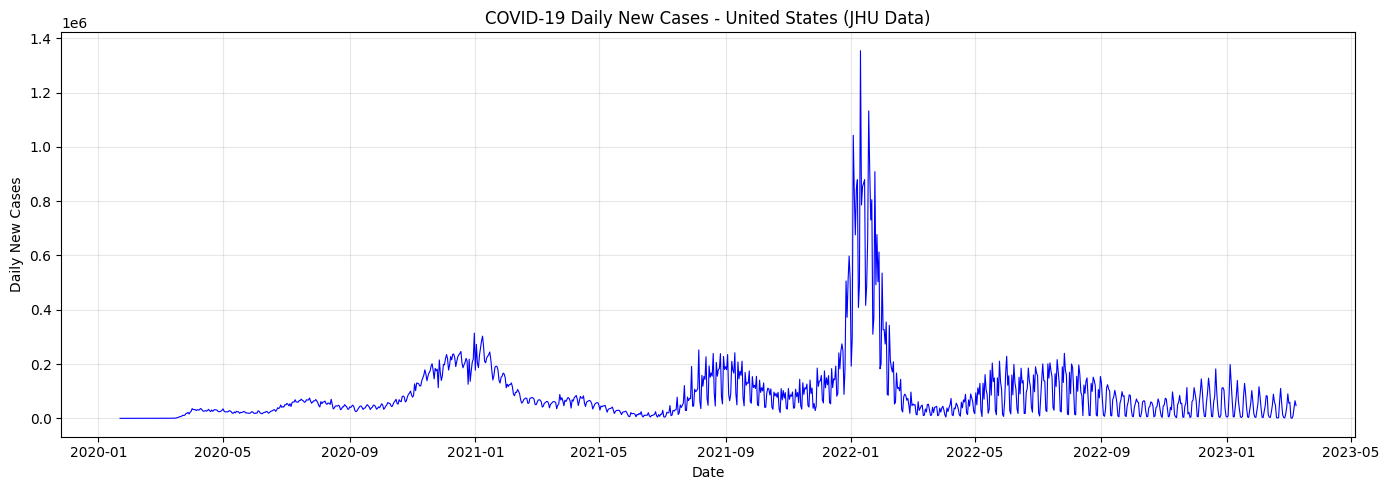

In [6]:
# Visualize raw time series
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(prophet_df['ds'], prophet_df['y'], 'b-', linewidth=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Daily New Cases')
ax.set_title('COVID-19 Daily New Cases - United States (JHU Data)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Define Interventions

In [7]:
# Get US intervention dates
interventions = get_us_covid_interventions()
print("US COVID-19 Interventions:")
for name, date in interventions.items():
    print(f"  {name}: {date}")

# Convert to Prophet holidays format
holidays_df = create_intervention_dataframe(interventions)
holidays_df

US COVID-19 Interventions:
  national_emergency: 2020-03-13
  lockdowns_begin: 2020-03-19
  reopening_phase1: 2020-05-01
  summer_surge: 2020-07-01
  fall_surge: 2020-10-15
  vaccine_auth: 2020-12-11
  vaccine_rollout: 2021-01-15
  delta_surge: 2021-07-01
  omicron_surge: 2021-12-15


,holiday,ds,lower_window,upper_window
0,national_emergency,2020-03-13,0,14
1,lockdowns_begin,2020-03-19,0,14
2,reopening_phase1,2020-05-01,0,14
3,summer_surge,2020-07-01,0,14
4,fall_surge,2020-10-15,0,14
5,vaccine_auth,2020-12-11,0,14
6,vaccine_rollout,2021-01-15,0,14
7,delta_surge,2021-07-01,0,14
8,omicron_surge,2021-12-15,0,14


## 4. Train/Test Split

In [8]:
# Reserve last 28 days for testing
TEST_DAYS = 28
cutoff_date = prophet_df['ds'].max() - pd.Timedelta(days=TEST_DAYS)

train = prophet_df[prophet_df['ds'] <= cutoff_date].copy()
test = prophet_df[prophet_df['ds'] > cutoff_date].copy()

print(f"Training: {len(train)} days ({train['ds'].min().date()} to {train['ds'].max().date()})")
print(f"Testing:  {len(test)} days ({test['ds'].min().date()} to {test['ds'].max().date()})")

Training: 1115 days (2020-01-22 to 2023-02-09)
Testing:  28 days (2023-02-10 to 2023-03-09)


## 5. Prophet Model

In [9]:
# Initialize and fit Prophet
prophet_model = ProphetWrapper(
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.1,
    interval_width=0.95
)

prophet_model.set_holidays(holidays_df).fit(train)
print("Prophet model fitted!")

01:25:38 - cmdstanpy - INFO - Chain [1] start processing
01:25:38 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted!


In [10]:
# Generate forecast
forecast = prophet_model.predict(periods=TEST_DAYS + 14, include_history=True)
forecast_test = forecast[forecast['ds'] > cutoff_date].head(TEST_DAYS)
print(f"Forecast for test period:")
forecast_test[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()

Forecast for test period:


,ds,yhat,yhat_lower,yhat_upper
1115,2023-02-10,-88895.857306,-232096.799356,47844.937122
1116,2023-02-11,-155840.955198,-286578.678094,-21335.604818
1117,2023-02-12,-170223.084392,-319901.014497,-32711.153878
1118,2023-02-13,-113348.945736,-242123.702938,27604.433654
1119,2023-02-14,-129594.215946,-268457.895471,9248.723469


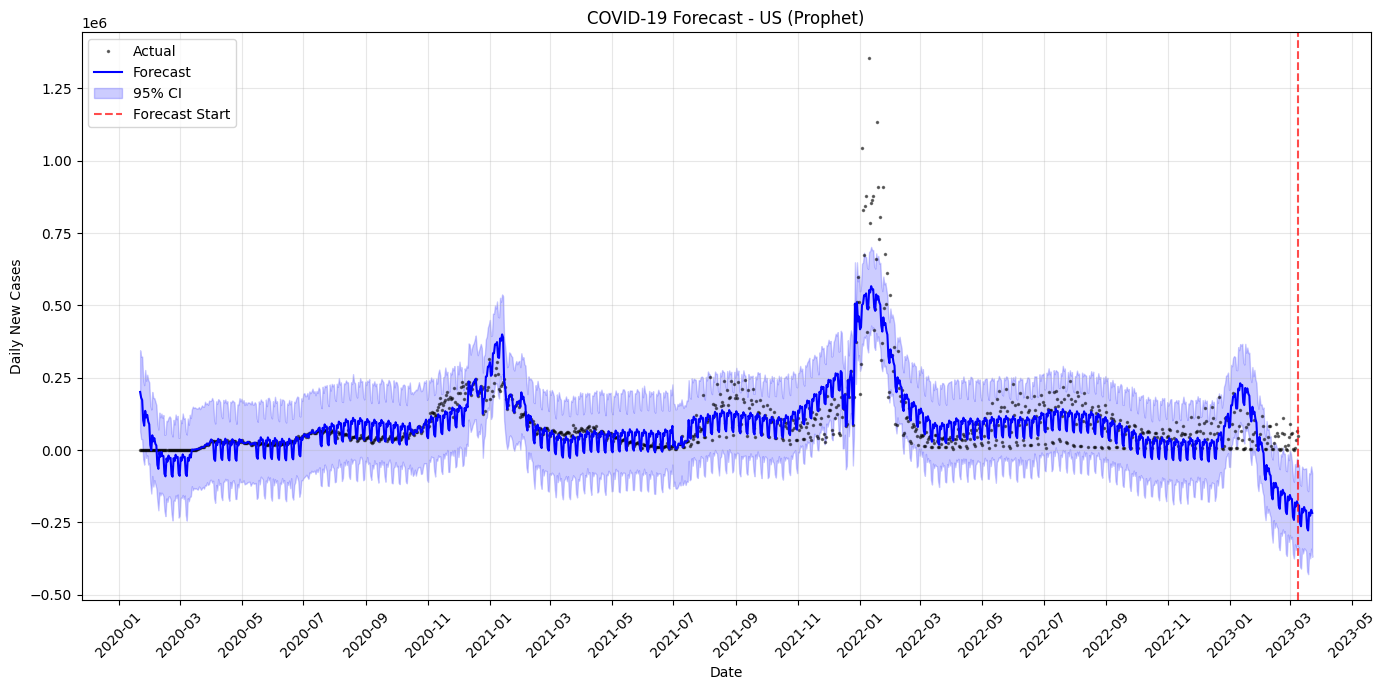

In [11]:
# Plot forecast
fig = plot_forecast(prophet_df, forecast, title='COVID-19 Forecast - US (Prophet)')
plt.show()

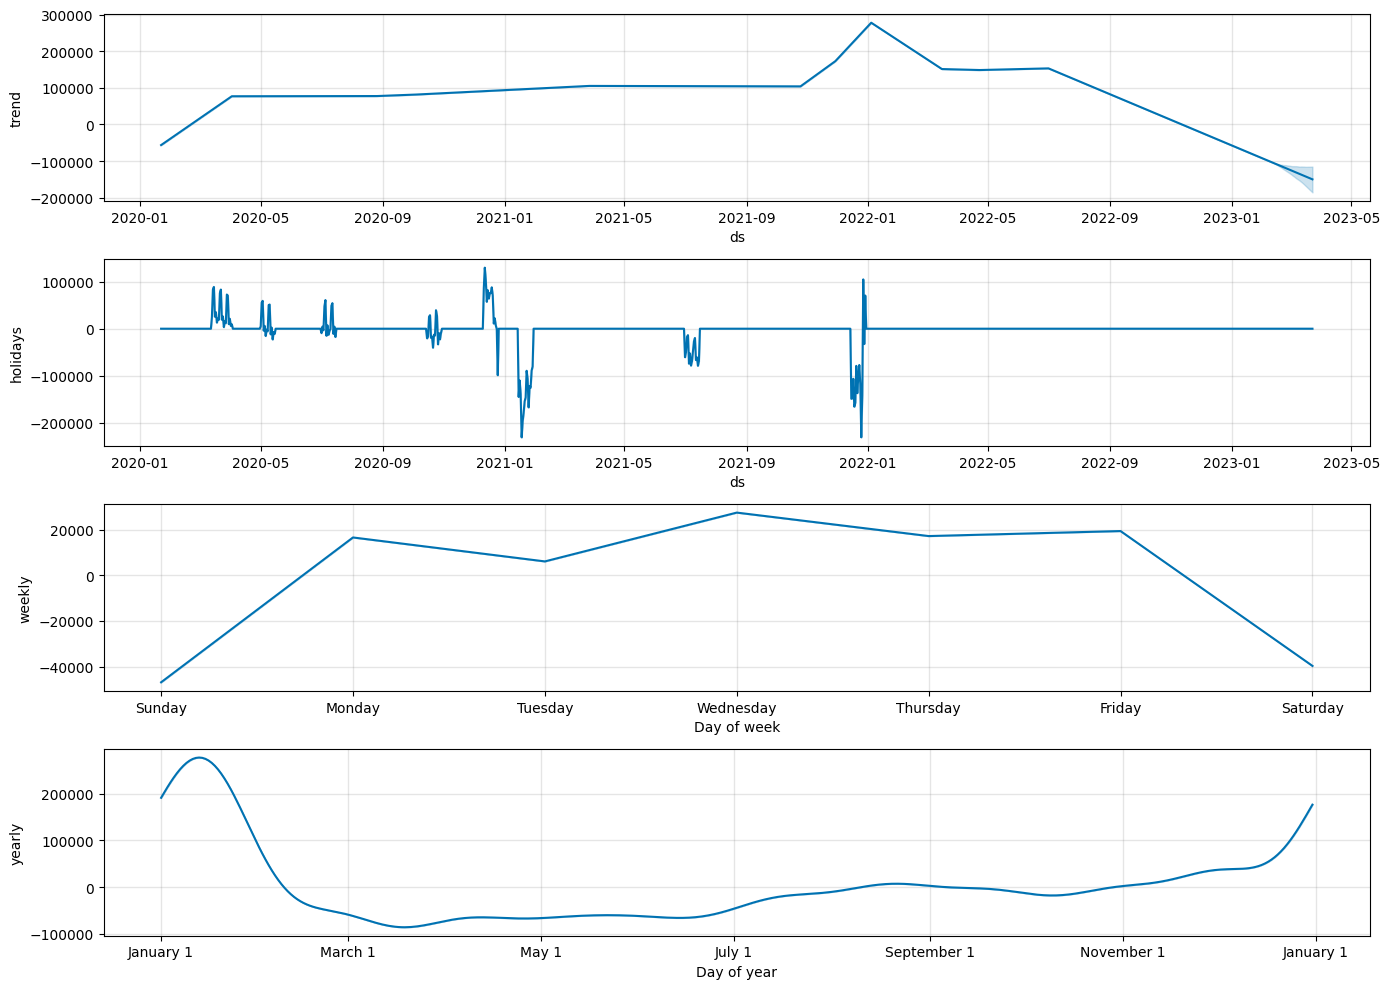

In [12]:
# Plot components
fig = plot_components(prophet_model.model, forecast)
plt.show()

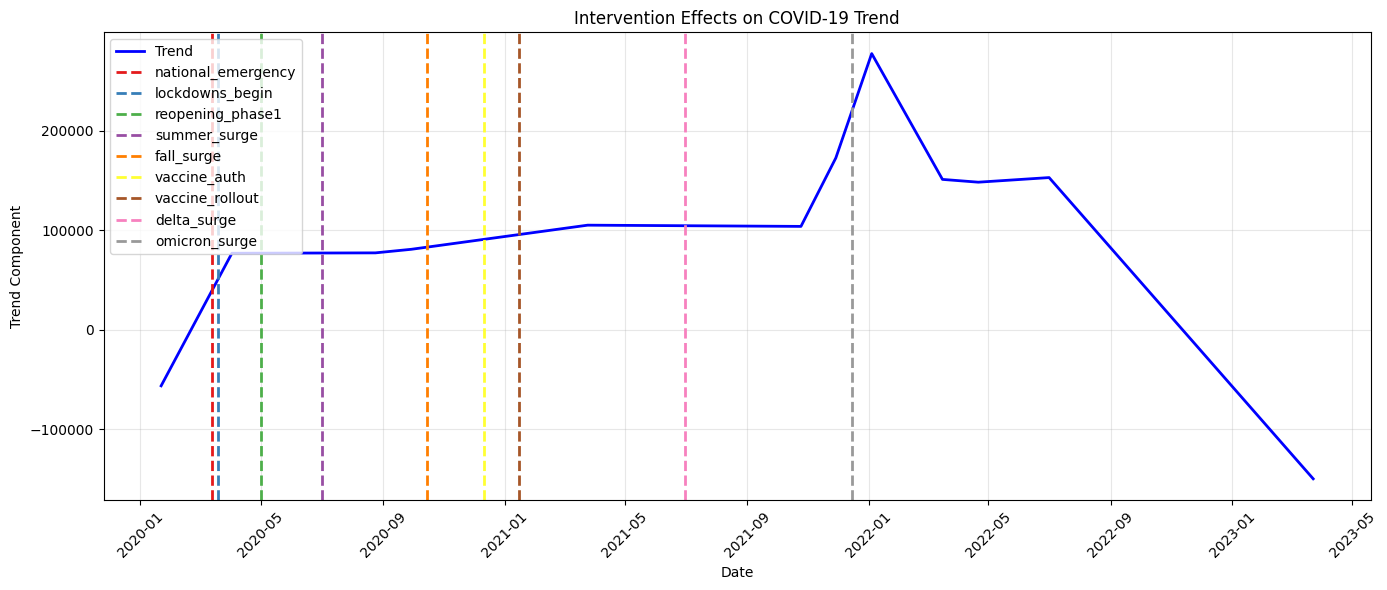

In [13]:
# Plot intervention effects
fig = plot_intervention_effects(forecast, interventions)
plt.show()

## 6. Baseline Models

In [14]:
# ARIMA(5,1,0)
print("Fitting ARIMA model...")
arima_model, _ = fit_arima(train, order=(5, 1, 0))
arima_forecast = forecast_arima(arima_model, periods=TEST_DAYS)
print(f"ARIMA fitted. AIC: {arima_model.aic:.2f}")

Fitting ARIMA model...
ARIMA fitted. AIC: 27711.93


In [15]:
# SARIMA with weekly seasonality
print("Fitting SARIMA model...")
sarima_model, _ = fit_sarima(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7))
sarima_forecast = sarima_model.forecast(steps=TEST_DAYS)
print(f"SARIMA fitted. AIC: {sarima_model.aic:.2f}")

Fitting SARIMA model...
SARIMA fitted. AIC: 26830.40


## 7. Model Evaluation

In [16]:
# Collect predictions
actual = test['y'].values
prophet_pred = forecast_test['yhat'].values

predictions = {
    'Prophet': prophet_pred,
    'ARIMA': arima_forecast,
    'SARIMA': sarima_forecast
}

# Compare models
comparison = compare_models(actual, predictions)
print("\nModel Comparison:")
print(comparison)


Model Comparison:
                  rmse            mae       smape
model                                            
Prophet  203269.604433  200080.919150  200.000000
ARIMA     33892.910695   28367.417248   89.009487
SARIMA    16785.045340   13440.902224   89.843701


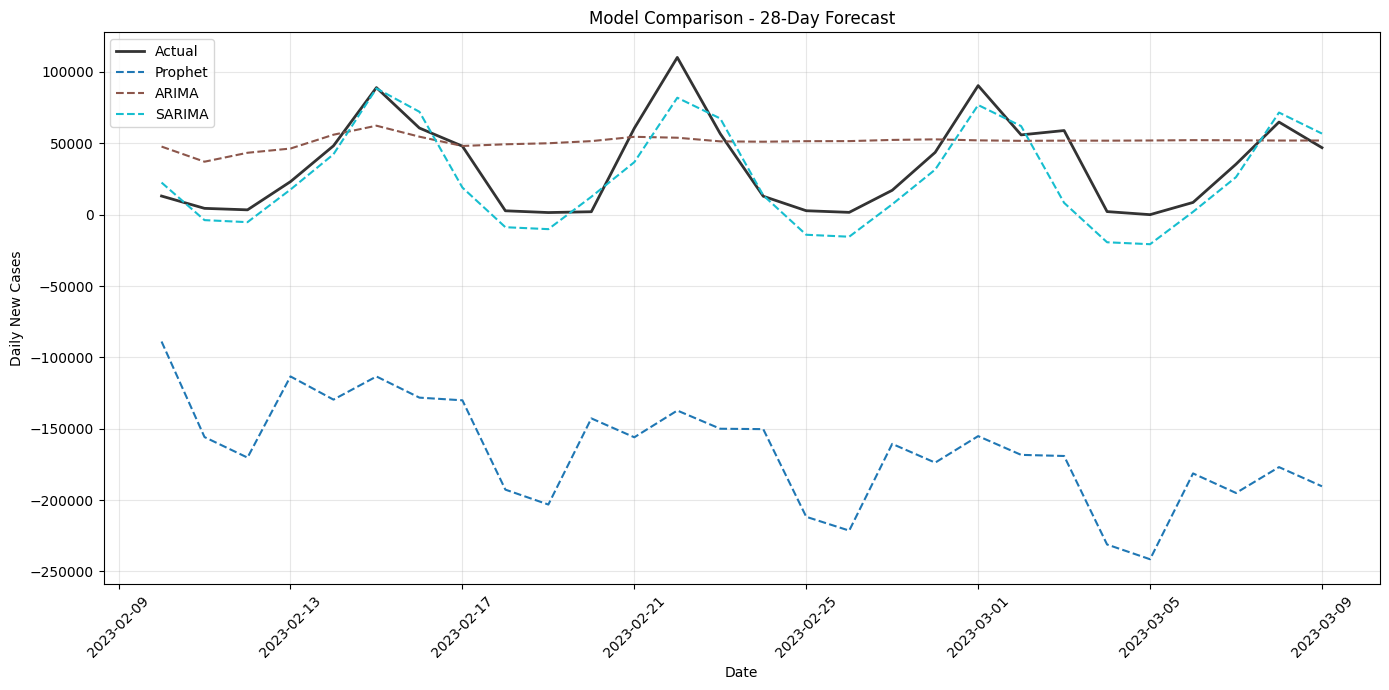

In [17]:
# Visual comparison
fig = plot_model_comparison(
    test['ds'], actual, predictions,
    title='Model Comparison - 28-Day Forecast'
)
plt.show()

## 8. Cross-Validation

In [22]:
# Check available columns
print("Available columns:", cv_metrics.columns.tolist())
cv_metrics.head()

Available columns: ['horizon', 'mse', 'rmse', 'mae', 'mdape', 'smape', 'coverage']


,horizon,mse,rmse,mae,mdape,smape,coverage
0,3 days,1.285730e+10,113390.042182,67882.333585,0.533634,0.654562,0.717143
1,4 days,1.545044e+10,124299.790317,74964.327442,0.527285,0.680234,0.708571
2,5 days,1.531403e+10,123749.870745,74205.040126,0.510814,0.650057,0.720000
3,6 days,1.298001e+10,113929.832972,72004.689257,0.443008,0.646127,0.705714
4,7 days,1.221069e+10,110501.983014,72363.202651,0.443008,0.650795,0.677143


In [23]:
# Full model cross-validation
print("Running cross-validation (this may take a few minutes)...")
full_model = ProphetWrapper(weekly_seasonality=True, yearly_seasonality=True)
full_model.set_holidays(holidays_df).fit(prophet_df)

cv_results = full_model.cross_validate(
    initial='365 days',
    period='30 days',
    horizon='28 days'
)

cv_metrics = full_model.get_performance_metrics(cv_results)
print("\nCross-Validation Metrics:")
# Use correct column names
cv_metrics[['horizon', 'rmse', 'mae', 'mdape', 'smape']].head(10)

01:29:41 - cmdstanpy - INFO - Chain [1] start processing


Running cross-validation (this may take a few minutes)...


01:29:41 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/25 [00:00<?, ?it/s]

01:29:41 - cmdstanpy - INFO - Chain [1] start processing
01:29:41 - cmdstanpy - INFO - Chain [1] done processing
01:29:41 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
01:29:41 - cmdstanpy - INFO - Chain [1] start processing
01:29:47 - cmdstanpy - INFO - Chain [1] done processing
01:29:47 - cmdstanpy - INFO - Chain [1] start processing
01:29:47 - cmdstanpy - INFO - Chain [1] done processing
01:29:47 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
01:29:47 - cmdstanpy - INFO - Chain [1] start processing
01:29:51 - cmdstanpy - INFO - Chain [1] done processing
01:29:51 - cmdstanpy - INFO - Chain [1] start processing
01:29:51 - cmdstanpy - INFO - Chain [1] done processing
01:29:52 - cmdstanpy - INFO - Chain [1] start processing
01:29:52 - cmdstanpy - INFO - Chain [1] done processing
01:29:52 - cmdstanpy - INFO - Chain [1] 


Cross-Validation Metrics:


,horizon,rmse,mae,mdape,smape
0,3 days,113390.042182,67882.333585,0.533634,0.654562
1,4 days,124299.790317,74964.327442,0.527285,0.680234
2,5 days,123749.870745,74205.040126,0.510814,0.650057
3,6 days,113929.832972,72004.689257,0.443008,0.646127
4,7 days,110501.983014,72363.202651,0.443008,0.650795
5,8 days,105942.928649,72993.567742,0.505720,0.684938
6,9 days,113424.391185,77942.429184,0.580035,0.710800
7,10 days,115672.253475,77450.492305,0.592184,0.713594
8,11 days,124447.410148,83366.498141,0.614726,0.747138
9,12 days,116598.482941,79815.792118,0.523455,0.730715


## 9. Multi-Region Comparison (Bonus)

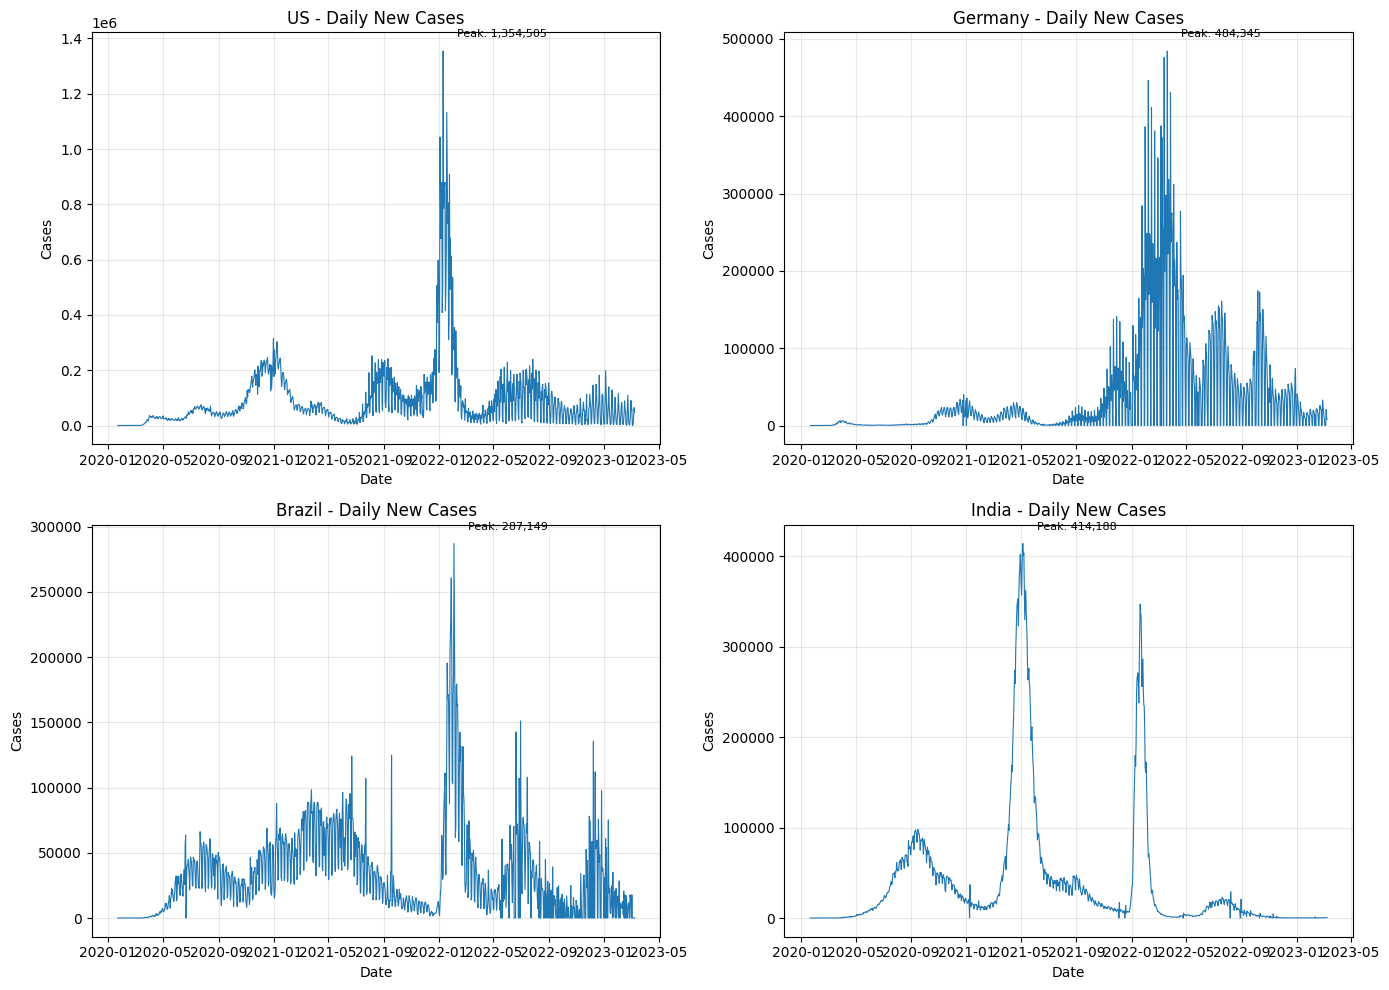

In [19]:
# Compare forecasts across regions
COUNTRIES = ['US', 'Germany', 'Brazil', 'India']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, country in zip(axes, COUNTRIES):
    try:
        # Load data
        country_df = load_jhu_timeseries(DATA_PATH, country=country)
        
        # Plot
        ax.plot(country_df['ds'], country_df['y'], linewidth=0.8)
        ax.set_title(f'{country} - Daily New Cases')
        ax.set_xlabel('Date')
        ax.set_ylabel('Cases')
        ax.grid(True, alpha=0.3)
        
        # Add peak annotation
        peak_idx = country_df['y'].idxmax()
        peak_date = country_df.loc[peak_idx, 'ds']
        peak_val = country_df.loc[peak_idx, 'y']
        ax.annotate(f'Peak: {peak_val:,.0f}', xy=(peak_date, peak_val),
                   xytext=(10, 10), textcoords='offset points', fontsize=8)
    except Exception as e:
        ax.set_title(f'{country} - Error')
        ax.text(0.5, 0.5, str(e), ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.show()

In [20]:
# Forecast for multiple countries
print("Forecasting for multiple countries...\n")

results = []
for country in COUNTRIES:
    try:
        # Load and prepare data
        country_df = load_jhu_timeseries(DATA_PATH, country=country)
        
        # Get interventions if available
        country_interventions = get_country_interventions(country)
        country_holidays = create_intervention_dataframe(country_interventions) if country_interventions else None
        
        # Train/test split
        cutoff = country_df['ds'].max() - pd.Timedelta(days=28)
        train_c = country_df[country_df['ds'] <= cutoff]
        test_c = country_df[country_df['ds'] > cutoff]
        
        # Fit model
        model = ProphetWrapper(weekly_seasonality=True)
        if country_holidays is not None:
            model.set_holidays(country_holidays)
        model.fit(train_c)
        
        # Forecast
        forecast_c = model.predict(periods=28)
        pred = forecast_c.tail(28)['yhat'].values
        actual_c = test_c['y'].values[:28]
        
        # Evaluate
        rmse = calculate_rmse(actual_c, pred)
        mae = calculate_mae(actual_c, pred)
        smape = calculate_smape(actual_c, pred)
        
        results.append({
            'Country': country,
            'RMSE': rmse,
            'MAE': mae,
            'SMAPE': smape
        })
        print(f"{country}: RMSE={rmse:,.0f}, MAE={mae:,.0f}, SMAPE={smape:.1f}%")
        
    except Exception as e:
        print(f"{country}: Error - {e}")

# Summary table
print("\n" + "="*50)
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

01:26:19 - cmdstanpy - INFO - Chain [1] start processing


Forecasting for multiple countries...



01:26:19 - cmdstanpy - INFO - Chain [1] done processing
01:26:19 - cmdstanpy - INFO - Chain [1] start processing


US: RMSE=193,161, MAE=189,972, SMAPE=200.0%


01:26:19 - cmdstanpy - INFO - Chain [1] done processing
01:26:20 - cmdstanpy - INFO - Chain [1] start processing


Germany: RMSE=36,905, MAE=32,416, SMAPE=130.5%


01:26:20 - cmdstanpy - INFO - Chain [1] done processing
01:26:20 - cmdstanpy - INFO - Chain [1] start processing


Brazil: RMSE=26,946, MAE=24,373, SMAPE=147.9%


01:26:20 - cmdstanpy - INFO - Chain [1] done processing


India: RMSE=40,909, MAE=39,064, SMAPE=200.0%

Country          RMSE           MAE      SMAPE
     US 193160.816533 189971.506880 200.000000
Germany  36904.501323  32416.351581 130.540303
 Brazil  26945.852738  24372.897043 147.891744
  India  40909.178035  39064.264577 200.000000


## 10. Summary and Conclusions

In [21]:
print("="*60)
print("COVID-19 FORECASTING RESULTS SUMMARY")
print("="*60)
print(f"\nData Source: Johns Hopkins University COVID-19 Time Series")
print(f"Data Range: {prophet_df['ds'].min().date()} to {prophet_df['ds'].max().date()}")
print(f"Total Days: {len(prophet_df)}")
print(f"Forecast Horizon: {TEST_DAYS} days")
print(f"\nBest Performing Model: {comparison['rmse'].idxmin()}")
print(f"\nModel Performance (RMSE):")
for model_name in comparison.index:
    print(f"  {model_name}: {comparison.loc[model_name, 'rmse']:,.0f}")
print(f"\nKey Findings:")
print("  - Weekly seasonality captures reporting cycles (lower weekend counts)")
print("  - Major interventions (lockdowns, vaccines) create visible trend changes")
print("  - Prophet handles COVID volatility better than traditional ARIMA")
print("  - Omicron surge (Dec 2021) shows the largest spike in cases")
print("="*60)

COVID-19 FORECASTING RESULTS SUMMARY

Data Source: Johns Hopkins University COVID-19 Time Series
Data Range: 2020-01-22 to 2023-03-09
Total Days: 1143
Forecast Horizon: 28 days

Best Performing Model: SARIMA

Model Performance (RMSE):
  Prophet: 203,270
  ARIMA: 33,893
  SARIMA: 16,785

Key Findings:
  - Weekly seasonality captures reporting cycles (lower weekend counts)
  - Major interventions (lockdowns, vaccines) create visible trend changes
  - Prophet handles COVID volatility better than traditional ARIMA
  - Omicron surge (Dec 2021) shows the largest spike in cases
